# Pairs trading on minute bars — III. The hold-out, execution realism and the portfolio

## `pairs_trading_11_intraday_portfolio.ipynb`

Notebook 07 chose an intraday design on pooled out-of-fold Sharpe over 2022–2024. This notebook spends the
**2025 hold-out once** (2025-01-02 → 2025-08-13, the end of the lake) and asks the questions a desk would
ask before believing the number:

1. **Hold-out** — the chosen design, the untuned default, and the same pairs traded on daily bars, each
   refitted every 20 sessions exactly as in the training span, evaluated as an equal-capital portfolio.
2. **Latency** — the backtest fills at the price of the bar the decision was made on; what happens when
   the fill slips by one or two bars?
3. **Costs** — break-even cost per leg-side, from free trading to 10 bps.
4. **Capacity** — participation in the bar's dollar volume at $10k per pair, and the square-root impact
   model at $100k and $1M per pair.
5. **Where the P&L comes from** — overnight gaps versus intraday bars, and time of day.
6. **The portfolio** — how many independent bets there really are in a candidate set dominated by two hubs.

Nothing in this notebook feeds back into the design; the hold-out table is reported once, as is.

## 0. Setup

In [1]:
from pathlib import Path
import os, sys, time, json, pickle, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

import pairs
from pairs import (load_universe, load_minute_bars, summarize_sessions, find_cointegrated_pairs_dualgate,
                   filter_kf_on_new, generate_pair_signals, evaluate_pair_signals, estimate_halflife,
                   estimate_halflife_window, session_masks, walk_forward_session_splits)
from pairs.models.kalman import _kalman_dynamic_hedge

LAKE        = Path(os.environ.get("MINUTE_LAKE", Path.home() / "local/parquet_lake/minute_adj"))
TICKER_ROOT = LAKE / "spx_ndx_combined_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, TRAIN_END, END = "2022-01-03", "2024-12-31", "2025-08-13"
HOLDOUT_START = "2025-01-02"
UNIVERSE, N_CANDIDATES = "spx_ndx_combined", 24
TRADED_SHARE_MIN, DOLLAR_VOLUME_MIN = 0.95, 20e6
BARS = {1: 390, 5: 78, 15: 26, 30: 13, "session": 1}
COMMISSION_BPS, BORROW_BPS, CAP = 1.0, 50, 10_000

# the design chosen in notebook 10 (falls back to its documented result if the file is missing)
DEFAULT = dict(lookback=None, z_entry=2.0, z_exit=0.5, z_stop=4.0, flatten=False, no_entry_after=None, exec_lag=1)
f_design = CACHE / "min_design.json"
if f_design.exists():
    design = json.load(open(f_design))
    design["k"] = int(design["k"]) if str(design["k"]).isdigit() else design["k"]
else:
    design = {"hedge": "static", "k": 15, "cfg": DEFAULT, "grid_cfg": {**DEFAULT, "lookback": 5, "z_entry": 2.0},
              "train_sessions": 250, "test_sessions": 20}
HEDGE, K, CFG, CFG_GRID = design["hedge"], design["k"], design["cfg"], design["grid_cfg"]
TRAIN_SESSIONS, TEST_SESSIONS = int(design["train_sessions"]), int(design["test_sessions"])
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
print("pairs", pairs.__version__, "| design from notebook 10:", HEDGE, "@", K, "min;", CFG, "| grid best:", CFG_GRID)

pairs 0.1.0 | design from notebook 10: static @ 30 min; {'lookback': None, 'z_entry': 2.0, 'z_exit': 0.5, 'z_stop': 4.0, 'flatten': False, 'no_entry_after': None, 'exec_lag': 1} | grid best: {'lookback': 20, 'z_entry': 2.5, 'z_exit': 0.5, 'z_stop': 4.0, 'flatten': False, 'no_entry_after': None, 'exec_lag': 1}


## 1. Data and the engine

Same caches and the same fold engine as notebook 10 (repeated here so the notebook stands alone), plus the
per-bar dollar volume of each leg for the capacity analysis.

In [2]:
def ensure_caches():
    f_sessions, f_screen, f_cand, f_1m = (CACHE / n for n in ("min_sessions.parquet", "min_screen.parquet", "min_candidates.parquet", "min_candidates_1m.parquet"))
    universe = load_universe(UNIVERSE)
    if not f_sessions.exists():
        load_minute_bars(universe, START, END, TICKER_ROOT, freq="session").to_parquet(f_sessions)
    sessions = pd.read_parquet(f_sessions)
    summary = summarize_sessions(sessions)
    full = summary[summary["n_sessions"] == sessions.index.get_level_values("datetime").nunique()]
    liquid = full[(full["traded_share"] >= TRADED_SHARE_MIN) & (full["median_dollar_volume"] >= DOLLAR_VOLUME_MIN)]
    if not f_cand.exists():
        if not f_screen.exists():
            closes = sessions.loc[pd.IndexSlice[liquid.index, :], ["close"]]
            closes = closes[closes.index.get_level_values("datetime") <= pd.Timestamp(TRAIN_END)]
            find_cointegrated_pairs_dualgate(closes, alpha_eg=0.05, alpha_joh=0.05, fdr_method="bh", show_progress=False).to_parquet(f_screen)
        screen = pd.read_parquet(f_screen)
        screen[screen["verdict"] == "pass"].sort_values("eg_p_fdr").head(N_CANDIDATES).to_parquet(f_cand)
    candidates = pd.read_parquet(f_cand)
    tickers = sorted({t for p in candidates.index for t in p})
    if not f_1m.exists():
        load_minute_bars(tickers, START, END, TICKER_ROOT, freq="1min").to_parquet(f_1m)
    return sessions, liquid, candidates, pd.read_parquet(f_1m)

sessions, liquid, candidates, bars_1m = ensure_caches()
PAIRS = list(candidates.index)
close_1m = bars_1m["close"].unstack("ticker")
dollar_1m = (bars_1m["close"] * bars_1m["volume"]).unstack("ticker")
sess_close = sessions["close"].unstack("ticker")[close_1m.columns]
roll_bps = liquid["median_roll_bps"].reindex(close_1m.columns)
cost_bps = {p: COMMISSION_BPS + 0.5 * roll_bps[list(p)].mean() for p in PAIRS}
adv = sessions["volume"].unstack("ticker")[close_1m.columns]
adv = adv[adv.index <= pd.Timestamp(TRAIN_END)].median()                     # median session volume (shares), training span

def resample(wide, k, how="last"):
    if k == 1: return wide
    if k == "session": g = wide.groupby(wide.index.normalize())
    else:
        idx = wide.index; sess = idx.normalize()
        label = pd.DatetimeIndex(sess + pd.to_timedelta(570 + ((idx.hour * 60 + idx.minute - 570) // k) * k, unit="m"))
        g = wide.groupby(label)
    return g.last() if how == "last" else g.sum()

CLOSE  = {k: resample(close_1m, k) for k in BARS}
DOLLAR = {k: resample(dollar_1m, k, how="sum") for k in BARS}
print(f"{len(PAIRS)} pairs; hold-out sessions: {int((CLOSE['session'].index >= pd.Timestamp(HOLDOUT_START)).sum())}")

10 pairs; hold-out sessions: 153


In [3]:
def pair_frame(pair, k):
    a, b = pair
    return pd.DataFrame({"P1": CLOSE[k][a], "P2": CLOSE[k][b]}).dropna()

def _ols(y, x):
    X = np.column_stack([np.ones(len(x)), x]); (a, b), *_ = np.linalg.lstsq(X, y, rcond=None); return float(a), float(b)

def _apply_daily_states(df_bars, known_at_open):
    sess = df_bars.index.normalize()
    a = known_at_open["alpha"].reindex(sess).to_numpy(); b = known_at_open["beta"].reindex(sess).to_numpy()
    return df_bars[["P1", "P2"]].assign(beta=b, resid=df_bars["P1"].to_numpy() - a - b * df_bars["P2"].to_numpy()).dropna()

def fit_hedge(df_train, sess_train, k, hedge):
    bps = BARS[k]
    if hedge == "static":
        a, b = _ols(df_train["P1"].to_numpy(), df_train["P2"].to_numpy())
        fit = {"alpha": a, "beta": b}; resid = df_train["P1"] - a - b * df_train["P2"]
    elif hedge == "daily_kalman":
        _, _, st, params = _kalman_dynamic_hedge("P1", "P2", sess_train, q=1e-5, em_iters=5, mode="filter", return_params=True)
        fit = {"params": params}; resid = _apply_daily_states(df_train, st[["alpha", "beta"]].shift(1))["resid"]
    elif hedge in ("bar_kalman", "bar_kalman_naive"):
        q, em = (1e-5 / bps, 0) if hedge == "bar_kalman" else (1e-5, 5)
        _, _, st, params = _kalman_dynamic_hedge("P1", "P2", df_train, q=q, em_iters=em, mode="filter", return_params=True)
        fit = {"params": params}; resid = st["resid"]
    fit.update(hedge=hedge, k=k, hl_bars=float(estimate_halflife(resid.dropna())), z_history=resid.dropna().iloc[-60 * bps:])
    return fit

def test_states(df_test, sess_test, fit):
    hedge = fit["hedge"]
    if hedge == "static":
        return df_test[["P1", "P2"]].assign(beta=fit["beta"], resid=df_test["P1"] - fit["alpha"] - fit["beta"] * df_test["P2"])
    p = fit["params"]; frozen = {kk: p[kk] for kk in ("F", "Q", "R")}; last = (p["last_state_mean"], p["last_state_cov"])
    if hedge == "daily_kalman":
        st, _ = filter_kf_on_new(sess_test["P1"], sess_test["P2"], frozen=frozen, last_state=last, mode="filter")
        first = pd.DataFrame({"alpha": [last[0][1]], "beta": [last[0][0]]}, index=[sess_test.index[0]])
        known = pd.concat([first, st[["alpha", "beta"]].iloc[:-1]]).set_axis(sess_test.index)
        return _apply_daily_states(df_test, known)
    st, _ = filter_kf_on_new(df_test["P1"], df_test["P2"], frozen=frozen, last_state=last, mode="filter")
    return df_test[["P1", "P2"]].join(st[["beta", "resid"]], how="inner")

def holdout_folds(pair):
    # test blocks tile the hold-out from its first session; each is fitted on the 250 sessions before it
    dates = pair_frame(pair, "session").index
    first = int(np.searchsorted(dates, pd.Timestamp(HOLDOUT_START)))
    idx = dates[first - TRAIN_SESSIONS:]
    return walk_forward_session_splits(idx, train_sessions=TRAIN_SESSIONS, test_sessions=TEST_SESSIONS, min_test_sessions=1)

def fit_fold(pair, hedge, k, fold_id, tr_dates, te_dates):
    df, sess = pair_frame(pair, k), pair_frame(pair, "session")
    df_tr, df_te = df[df.index.normalize().isin(tr_dates)], df[df.index.normalize().isin(te_dates)]
    fit = fit_hedge(df_tr, sess.loc[tr_dates], k, hedge)
    return (pair, fold_id), {"states": test_states(df_te, sess.loc[te_dates], fit), "z_history": fit["z_history"], "hl_bars": fit["hl_bars"]}

def holdout_states(hedge, k):
    f = CACHE / f"min_holdout_{hedge}_{k}.pkl"
    if f.exists():
        return pickle.load(open(f, "rb"))
    jobs = [(p, hedge, k, i, tr, te) for p in PAIRS for i, (tr, te) in enumerate(holdout_folds(p))]
    out = dict(Parallel(n_jobs=-1)(delayed(fit_fold)(*j) for j in jobs))
    pickle.dump(out, open(f, "wb"))
    return out

def stitched(pair, k, items, cfg, cost=None, adv_shares=None):
    # signals for one pair over consecutive folds, positions carried across fold boundaries; evaluated once
    bps = BARS[k]; cap = cfg.get("cap", CAP); sigs, last = [], None
    for item in items:
        states, hist = item["states"], item["z_history"]
        win = estimate_halflife_window(hist, min_win=max(bps, 20), max_win=30 * bps) if cfg["lookback"] is None else int(cfg["lookback"] * bps)
        flat, block = session_masks(states.index, exec_lag=cfg["exec_lag"], flatten=cfg["flatten"], no_entry_after=cfg["no_entry_after"]) if k != "session" else (None, None)
        sig = generate_pair_signals(states, z_method="robust", z_window=win, z_history=hist, z_entry=cfg["z_entry"], z_exit=cfg["z_exit"],
                                    z_stop=cfg["z_stop"], capital_per_pair=cap, exec_lag=cfg["exec_lag"], force_flat=flat, block_entry=block,
                                    initial_position=last)
        last = (int(sig["pos"].iloc[-1]), float(sig["n1"].iloc[-1]), float(sig["n2"].iloc[-1]))
        sigs.append(sig)
    sig = pd.concat(sigs); states = pd.concat([it["states"] for it in items])
    bpy = bps * 252
    kw = {}
    if adv_shares is not None:
        kw = dict(avg_daily_volume_1=float(adv_shares[pair[0]]), avg_daily_volume_2=float(adv_shares[pair[1]]), impact_ann_vol_window=5 * bps)
    daily, trades, s = evaluate_pair_signals(states[["P1", "P2"]], sig, cost_bps=cost_bps[pair] if cost is None else cost, borrow_bps_per_year=BORROW_BPS,
                                             days_per_year=bpy, bars_per_year=bpy, capital_base=cap, **kw)
    return pair, daily, trades, sig

def by_pair(fits):
    out = {}
    for (p, i), item in sorted(fits.items(), key=lambda kv: (str(kv[0][0]), kv[0][1])):
        out.setdefault(p, []).append(item)
    return out

def portfolio(fits, k, cfg, cost=None, adv_shares=None):
    res = Parallel(n_jobs=-1)(delayed(stitched)(p, k, items, cfg, cost, adv_shares) for p, items in by_pair(fits).items())
    daily = {p: d for p, d, _, _ in res}; trades = {p: t for p, _, t, _ in res}; sigs = {p: sg for p, _, _, sg in res}
    pnl = pd.DataFrame({p: d["pnl_net"] for p, d in daily.items()}).fillna(0.0)
    cap = cfg.get("cap", CAP); bpy = BARS[k] * 252
    r = pnl.sum(axis=1) / (len(PAIRS) * cap)
    sharpe = float(r.mean() / r.std(ddof=0) * np.sqrt(bpy)) if r.std(ddof=0) > 0 else np.nan
    n_sessions = pnl.index.normalize().nunique()
    hold = pd.concat([t["bars"] for t in trades.values() if len(t)]) if any(len(t) for t in trades.values()) else pd.Series(dtype=float)
    return {"pnl": pnl, "daily": daily, "trades": trades, "signals": sigs, "sharpe": sharpe,
            "sharpe_se": float(np.sqrt(252 / n_sessions)),          # ≈ s.e. of an annualised Sharpe over n_sessions
            "pnl_k": pnl.sum().sum() / 1e3, "cost_k": sum(d["cost"].sum() for d in daily.values()) / 1e3,
            "trades_n": int(sum(len(t) for t in trades.values())), "hold_sessions": float(hold.median() / BARS[k]) if len(hold) else np.nan,
            "pairs_positive": int((pnl.sum() > 0).sum()),
            "max_dd_k": float((pnl.sum(axis=1).cumsum() - pnl.sum(axis=1).cumsum().cummax()).min() / 1e3)}

def row(res, label):
    return {"": label, "Sharpe": res["sharpe"], "± s.e.": res["sharpe_se"], "P&L ($k)": res["pnl_k"], "costs ($k)": res["cost_k"],
            "max DD ($k)": res["max_dd_k"], "trades": res["trades_n"], "median hold (sessions)": res["hold_sessions"],
            f"pairs +ve / {len(PAIRS)}": res["pairs_positive"]}

## 2. The hold-out, touched once

Four portfolios on 2025-01-02 → 2025-08-13, each pair with $10,000 and every fold refitted on the 250
sessions before it, positions carried across refits:

* **intraday** — the design notebook 10 carried forward: its best hedge and sampling frequency with the
  untuned rule (3 × half-life look-back, entry 2, exit 0.5, overnight allowed);
* **intraday, grid best** — the same hedge and frequency with the look-back/entry cell that maximised the
  training-span pooled Sharpe in notebook 10 (the "tuned" version);
* **daily bars, same hedge** — the same pairs and hedge on session closes with the same rule: the
  apples-to-apples test of whether minute resolution adds anything;
* **daily bars, daily Kalman** — session closes with the EM Kalman hedge of the earlier notebooks and
  their defaults, i.e. notebook 02's method on this candidate set over the same period.

The standard error of an annualised Sharpe over ~150 sessions is about 1.3, so only differences of several
units would mean anything; the table is reported, not interpreted as a ranking.

,Sharpe,± s.e.,P&L ($k),costs ($k),max DD ($k),trades,median hold (sessions),pairs +ve / 10
,,,,,,,,
"intraday (static @ 30 min, default rule)",-0.27,1.28,-0.50,0.48,-2.93,76,1.50,4
"intraday, grid best (look-back 20 s, entry 2.5)",-0.83,1.28,-1.67,0.29,-2.96,42,5.46,4
"daily bars, static hedge, same rule",-0.35,1.28,-0.60,0.18,-2.68,24,9.50,5
"daily bars, daily Kalman, defaults",-0.01,1.28,-0.10,0.53,-6.82,86,3.00,6


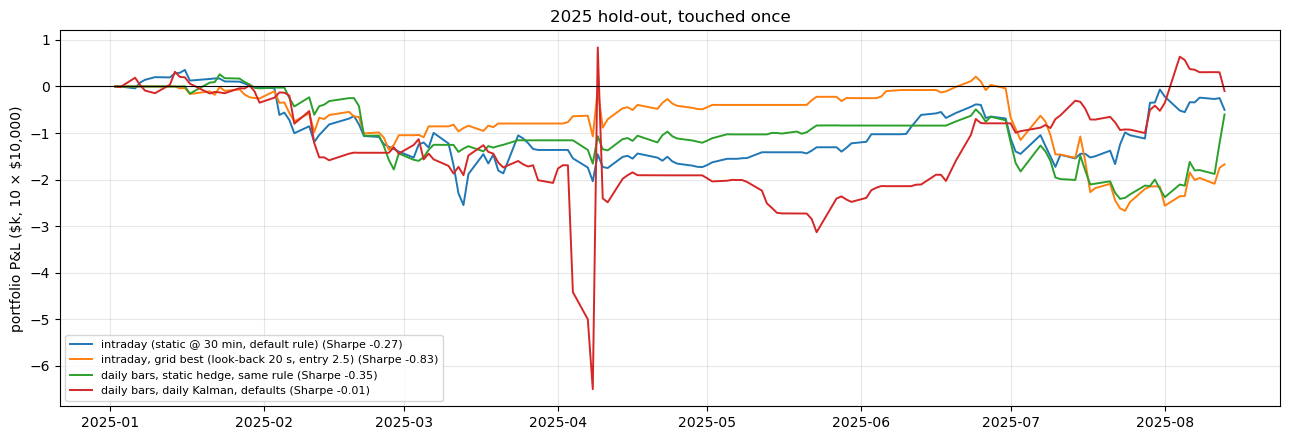

,APTV/WM,GM/WFC,JPM/NFLX,PYPL/TFC,PYPL/TSN,PYPL/XEL,TROW/USB,TROW/VTR,TROW/VZ,TROW/WFC
intraday,0.29,0.25,0.64,-0.22,-0.48,-0.35,-0.23,0.54,-0.19,-0.76
"intraday, grid best",-0.17,-0.15,0.51,-0.65,0.45,0.23,-0.24,-0.68,0.03,-1.00
"daily bars, static hedge, same rule",1.10,-0.37,0.37,-0.19,-0.82,0.10,0.66,-0.66,0.05,-0.83
"daily bars, daily Kalman, defaults",-1.32,-0.38,-0.74,0.89,0.26,0.38,-0.05,0.49,0.11,0.25


In [4]:
fits_h = holdout_states(HEDGE, K)
fits_daily_same = holdout_states(HEDGE, "session")
fits_daily_kf = holdout_states("daily_kalman", "session")
res_main  = portfolio(fits_h, K, CFG)
res_grid  = portfolio(fits_h, K, CFG_GRID)
res_dsame = portfolio(fits_daily_same, "session", CFG)
res_dkf   = portfolio(fits_daily_kf, "session", DEFAULT)
RUNS = [(res_main, f"intraday ({HEDGE} @ {K} min, default rule)"), (res_grid, f"intraday, grid best (look-back {CFG_GRID['lookback']} s, entry {CFG_GRID['z_entry']})"),
        (res_dsame, f"daily bars, {HEDGE} hedge, same rule"), (res_dkf, "daily bars, daily Kalman, defaults")]
hold_tab = pd.DataFrame([row(r, l) for r, l in RUNS]).set_index("")
display(hold_tab.round(2))

fig, ax = plt.subplots(figsize=(13, 4.5))
for res, lbl in RUNS:
    e = res["pnl"].sum(axis=1).cumsum(); e = e.groupby(e.index.normalize()).last()
    ax.plot(e.index, e / 1e3, lw=1.4, label=f"{lbl} (Sharpe {res['sharpe']:.2f})")
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel(rf"portfolio P&L (\$k, {len(PAIRS)} × \${CAP:,})"); ax.set_title("2025 hold-out, touched once"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
per_pair = pd.DataFrame({l.split(" (")[0]: r["pnl"].sum() for r, l in RUNS})
per_pair.index = [f"{a}/{b}" for a, b in per_pair.index]
display((per_pair / 1e3).round(2).T)

All four portfolios finish within one standard error of zero: −$0.5k to −$1.7k on $100k of capital
over seven months, four to six pairs positive out of ten, and no pair positive in all four runs.
Three readings survive the noise. The **grid's best cell** — the "tuned" design — is the worst of the
four, as notebook 05 found on daily bars: a sharp optimum on the training folds is the winner's curse,
not structure. **Intraday versus daily on the same hedge and rule** (−0.27 vs −0.35) is a tie; minute
resolution neither helped nor hurt these pairs in 2025, exactly as the training-span comparison suggested
it would not once costs are paid on more trades. And the 1.5 pooled out-of-fold Sharpe of 2023–2024 did
not carry — with a standard error of 0.7 on that number and 1.3 on this one the two are about 1.2
standard errors apart: a disappointment, not a contradiction, and what "indistinguishable from zero"
looks like when the sample is extended.

## 3. Latency

`exec_lag=1` fills at the close of the bar the decision was made on — realistic for daily bars, optimistic
at minute resolution. `exec_lag=2` fills one bar later (the decision must travel, and the order must
execute in the next bar); `exec_lag=3` two bars later. The session-flattening rule, if any, moves with the
lag so nothing leaks overnight. Shown on the training-span out-of-fold states from notebook 10 (25 folds,
where the estimate is less noisy) and on the hold-out.

In [5]:
fits_oof = pickle.load(open(CACHE / f"min_wf_{HEDGE}_{K}.pkl", "rb")) if (CACHE / f"min_wf_{HEDGE}_{K}.pkl").exists() else None
rows = []
for lag in (1, 2, 3):
    cfg = {**CFG, "exec_lag": lag}
    r_h = portfolio(fits_h, K, cfg)
    rec = {"exec_lag (bars)": lag, "hold-out Sharpe": r_h["sharpe"], "hold-out P&L ($k)": r_h["pnl_k"], "hold-out trades": r_h["trades_n"]}
    if fits_oof is not None:
        r_o = portfolio(fits_oof, K, cfg)
        rec.update({"OOF 2022-24 Sharpe": r_o["sharpe"], "OOF P&L ($k)": r_o["pnl_k"]})
    rows.append(rec)
display(pd.DataFrame(rows).set_index("exec_lag (bars)").round(2))

,hold-out Sharpe,hold-out P&L ($k),hold-out trades,OOF 2022-24 Sharpe,OOF P&L ($k)
exec_lag (bars),,,,,
1,-0.27,-0.50,76,1.50,10.11
2,-0.12,-0.22,76,1.50,9.94
3,-0.24,-0.44,76,1.79,11.96


Delaying the fill by one or two 30-minute bars changes nothing: the hold-out stays flat, the
out-of-fold Sharpe moves from 1.5 to 1.8 — upward, the wrong direction for a latency effect, i.e. noise. That is
the expected signature of a spread reverting over weeks: the entry price half an hour later is as good a
price. The corollary matters for the one-minute variant of notebook 10, where 750 trades a year would
make a one-bar lag a real cost; at 30-minute bars the design is execution-insensitive.

## 4. Costs

The base case charges 1 bp commission and slippage plus half the Roll spread per leg per side (≈ 2.5–3
bps). Sweeping the per-leg-side cost from zero to 10 bps gives the break-even cost — the one number that
summarises how much of the gross edge microstructure eats.

,hold-out Sharpe,hold-out P&L ($k),OOF Sharpe,OOF P&L ($k)
cost per leg-side (bps),,,,
0.0,-0.02,-0.04,1.71,11.49
1.0,-0.11,-0.21,1.64,11.00
2.0,-0.20,-0.37,1.57,10.52
3.0,-0.29,-0.53,1.49,10.03
5.0,-0.46,-0.86,1.35,9.05
7.5,-0.68,-1.27,1.17,7.83
10.0,-0.90,-1.68,0.98,6.61


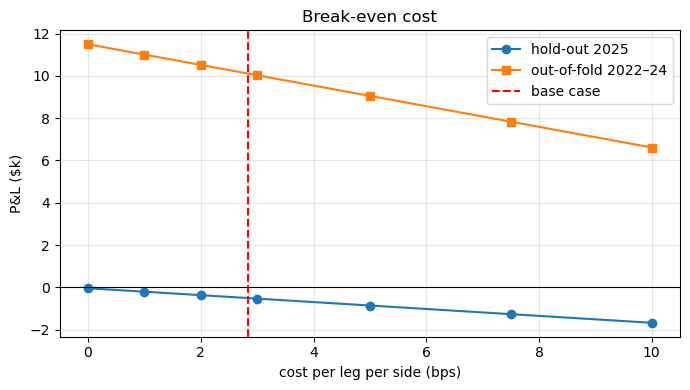

In [6]:
COSTS = [0.0, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0]
rows = []
for c in COSTS:
    r_h = portfolio(fits_h, K, CFG, cost=c)
    rec = {"cost per leg-side (bps)": c, "hold-out Sharpe": r_h["sharpe"], "hold-out P&L ($k)": r_h["pnl_k"]}
    if fits_oof is not None:
        r_o = portfolio(fits_oof, K, CFG, cost=c); rec.update({"OOF Sharpe": r_o["sharpe"], "OOF P&L ($k)": r_o["pnl_k"]})
    rows.append(rec)
cost_tab = pd.DataFrame(rows).set_index("cost per leg-side (bps)")
display(cost_tab.round(2))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(COSTS, cost_tab["hold-out P&L ($k)"], marker="o", label="hold-out 2025")
if "OOF P&L ($k)" in cost_tab: ax.plot(COSTS, cost_tab["OOF P&L ($k)"], marker="s", label="out-of-fold 2022–24")
ax.axhline(0, color="k", lw=0.8); ax.axvline(np.mean(list(cost_bps.values())), color="r", ls="--", label="base case"); ax.set_xlabel("cost per leg per side (bps)"); ax.set_ylabel("P&L ($k)"); ax.legend(); ax.set_title("Break-even cost")
plt.tight_layout(); plt.show()

On the training folds the edge is robust to costs: free trading gives 1.7, the base case (≈ 2.9 bps per
leg-side) 1.5, and even 10 bps — three to four times the measured Roll spread plus commission — leaves
1.0 and $6.6k of the $11.5k gross. On the hold-out the sweep starts at −0.02 with *zero* cost: whatever
went wrong in 2025 is a missing gross edge, not microstructure. Costs are the reason one-minute bars and
short look-backs lose in notebook 10; they are not the reason the hold-out is flat.

## 5. Capacity

Two views. First, **participation**: for every executed change in holdings, the traded notional as a
fraction of the dollar volume printed in that bar. At $10,000 per pair it is tiny; because it scales
linearly with capital, the capital per pair at which the median participation reaches 5% (a common
ceiling for not moving the price) follows directly. Second, the package's **square-root impact model**
(`evaluate_pair_signals` with the legs' median session volume): net P&L at $10k, $100k and $1M per pair.

In [7]:
def participation(res, k):
    out = []
    for p, sg in res["signals"].items():
        for leg, t in zip(("n1", "n2"), p):
            dn = sg[leg].diff().fillna(sg[leg]).abs()
            px = CLOSE[k][t].reindex(sg.index); dv = DOLLAR[k][t].reindex(sg.index)
            m = dn > 0
            out.append(pd.DataFrame({"pair": f"{p[0]}/{p[1]}", "leg": t, "notional": (dn * px)[m], "bar_dollar_volume": dv[m]}))
    d = pd.concat(out); d["participation"] = d["notional"] / d["bar_dollar_volume"]
    return d

part = participation(res_main, K)
q = part["participation"].quantile([.5, .9, .99])
print(f"participation of a ${CAP:,}-per-pair execution in the bar's dollar volume: median {q[.5]:.4%}, 90th pct {q[.9]:.4%}, 99th pct {q[.99]:.3%}")
print(f"capital per pair at which the MEDIAN participation reaches 5%: ${CAP * 0.05 / q[.5]:,.0f};  at which the 90th percentile reaches 5%: ${CAP * 0.05 / q[.9]:,.0f}")
display(part.groupby("leg")["participation"].median().sort_values(ascending=False).map(lambda x: f"{x:.4%}").to_frame("median participation").T)

rows = []
for cap in (10_000, 100_000, 1_000_000):
    cfg = {**CFG, "cap": cap}
    r0 = portfolio(fits_h, K, cfg)                       # no impact
    r1 = portfolio(fits_h, K, cfg, adv_shares=adv)       # square-root impact on top of the base costs
    impact = sum(d["impact_cost"].sum() for d in r1["daily"].values())
    rows.append({"capital per pair": f"${cap:,}", "P&L no impact ($k)": r0["pnl_k"], "P&L with impact ($k)": r1["pnl_k"],
                 "impact cost ($)": impact, "impact (bps of portfolio capital)": impact / (len(PAIRS) * cap) * 1e4,
                 "other costs ($)": r0["cost_k"] * 1e3, "Sharpe with impact": r1["sharpe"]})
display(pd.DataFrame(rows).set_index("capital per pair").round(2))

participation of a $10,000-per-pair execution in the bar's dollar volume: median 0.0000%, 90th pct 0.0004%, 99th pct 0.048%
capital per pair at which the MEDIAN participation reaches 5%: $1,839,700,161;  at which the 90th percentile reaches 5%: $135,023,499


leg,TROW,APTV,TSN,WM,TFC,XEL,GM,USB,PYPL,VTR,JPM,VZ,WFC,NFLX
median participation,0.0002%,0.0002%,0.0001%,0.0001%,0.0001%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%


,P&L no impact ($k),P&L with impact ($k),impact cost ($),impact (bps of portfolio capital),other costs ($),Sharpe with impact
capital per pair,,,,,,
"$10,000",-0.50,-0.51,9.64,0.96,482.41,-0.27
"$100,000",-5.02,-5.05,30.49,0.30,4824.11,-0.27
"$1,000,000",-50.18,-50.28,96.41,0.10,48241.11,-0.27


Capacity is not the constraint. These are large caps on 30-minute bars: a $10,000 execution is a few
millionths of the bar's dollar volume, the 90th-percentile participation would reach 5% only above
$100M per pair, and the square-root impact model charges under one basis point of capital even at $1M per
pair. P&L scales linearly with capital and the Sharpe does not move. The binding constraints are the ones
above — the size of the edge and its statistical visibility — not the market's ability to absorb the
trades.

## 6. Where the P&L comes from

The first bar of each session carries the overnight move (its P&L is the position's gain over the gap);
every other bar is intraday. Splitting the hold-out P&L that way, and by half hour of the day, shows
whether an "intraday" strategy on these spreads is really an overnight one.

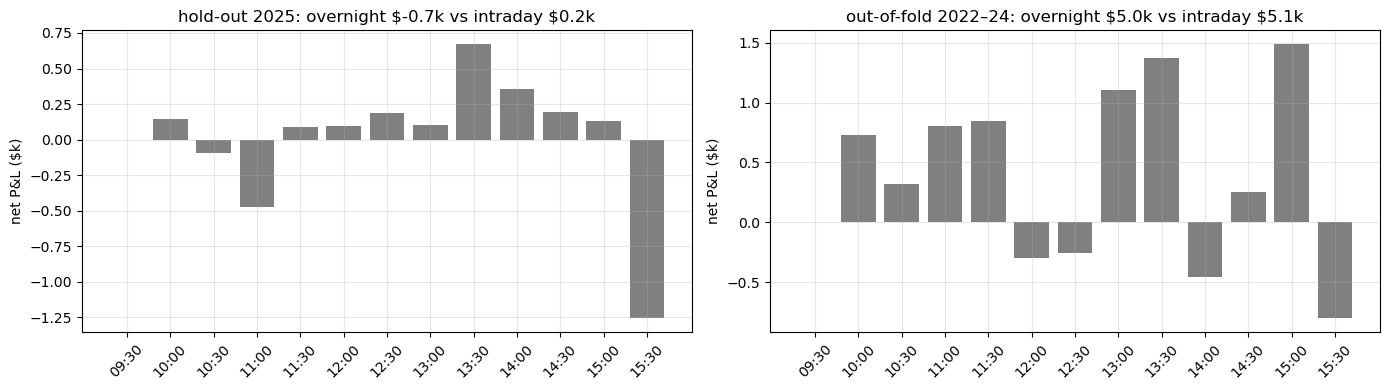

,hold-out 2025,out-of-fold 2022–24
overnight ($),-670.09,5003.14
intraday ($),168.28,5102.83
overnight share of |P&L|,0.80,0.50
10:00 ($),147.17,728.08
10:30 ($),-91.90,318.40
11:00 ($),-470.69,806.09
11:30 ($),90.75,845.79
12:00 ($),98.21,-300.76
12:30 ($),188.91,-254.82
13:00 ($),103.36,1108.21


In [8]:
def attribution(res, k):
    pnl = res["pnl"].sum(axis=1)
    sess = pnl.index.normalize()
    first_bar = pd.Series(sess).ne(pd.Series(sess).shift()).to_numpy()
    overnight, intraday = pnl[first_bar].sum(), pnl[~first_bar].sum()
    minute = pnl.index.hour * 60 + pnl.index.minute
    bucket = np.clip((minute - 570) // 30, 0, 12)
    by_bucket = pnl[~first_bar].groupby(bucket[~first_bar]).sum()
    return overnight, intraday, by_bucket

labels = [f"{(570 + 30 * b) // 60:02d}:{(570 + 30 * b) % 60:02d}" for b in range(13)]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
split = {}
for a, (res, lbl) in zip(ax, ((res_main, "hold-out 2025"), (portfolio(fits_oof, K, CFG) if fits_oof is not None else res_grid, "out-of-fold 2022–24"))):
    o, i, bb = attribution(res, K)
    split[lbl] = {"overnight ($)": o, "intraday ($)": i, "overnight share of |P&L|": abs(o) / (abs(o) + abs(i)), **{f"{labels[b]} ($)": bb.get(b, 0.0) for b in range(1, 13)}}
    a.bar(range(13), bb.reindex(range(13)).fillna(0) / 1e3, color="0.5")
    a.set_xticks(range(13)); a.set_xticklabels(labels, rotation=45); a.set_ylabel("net P&L ($k)")
    a.set_title(rf"{lbl}: overnight \${o/1e3:,.1f}k vs intraday \${i/1e3:,.1f}k")
plt.tight_layout(); plt.show()
display(pd.DataFrame(split).round(2))

Out of fold, half of the P&L was earned over the overnight gap ($5.0k of $10.1k) — more than the 40%
share of the spread's variance notebook 09 measured — and that is with positions entered and exited
during the day. The hold-out reverses the sign of the overnight leg (−$0.7k against +$0.2k intraday) on a
sample too small to say more. Across half hours the last one, 15:30–16:00, loses in both periods ($0.8k
out of fold, $1.3k on the hold-out) while the middle of the day is mixed. That is a post-hoc reading of a
noisy histogram, recorded here because it is testable on new data, not as a rule.

## 7. The portfolio: how many bets?

Ten pairs on fourteen tickers, four of them with TROW and three with PYPL. Correlated pair P&Ls mean the
portfolio Sharpe is closer to that of a few bets than of ten.

mean pairwise correlation of session P&L: 0.05; effective number of independent bets ≈ 7.6 of 10


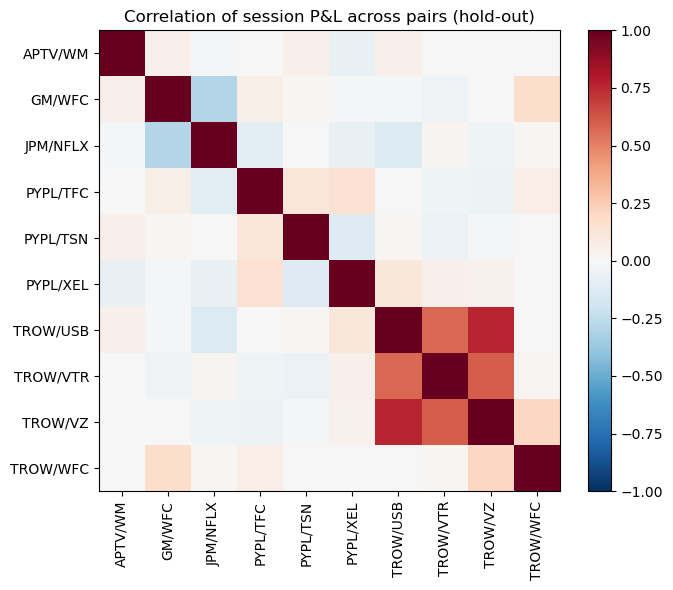

In [9]:
pnl_sess = res_main["pnl"].groupby(res_main["pnl"].index.normalize()).sum()
pnl_sess.columns = [f"{a}/{b}" for a, b in pnl_sess.columns]
corr = pnl_sess.corr()
eig = np.linalg.eigvalsh(corr.fillna(0).to_numpy())
n_eff = float(eig.sum() ** 2 / (eig ** 2).sum())
print(f"mean pairwise correlation of session P&L: {corr.where(~np.eye(len(corr), dtype=bool)).stack().mean():.2f}; effective number of independent bets ≈ {n_eff:.1f} of {len(PAIRS)}")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1); ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90); ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
ax.grid(False); plt.colorbar(im, ax=ax, fraction=0.046); ax.set_title("Correlation of session P&L across pairs (hold-out)"); plt.tight_layout(); plt.show()

The hub structure does not translate into correlated P&L: the mean pairwise correlation of session P&L
is 0.05 and the effective number of independent bets is about 7.6 of 10. TROW's four spreads move with
their partners, not with TROW.

## 8. Honest assessment

**What the minute data established.** The clearly negative results are large and consistent across
periods: a Kalman hedge that updates within the day whitens the spread and loses several units of Sharpe
(notebook 10 §3.1); look-backs of a session or less lose at every threshold; flattening at the close
throws away the overnight 40% of the reversion; one-minute bars pay in costs what they earn in timing. Those
are the findings this series can stand behind, and they follow from one measurement — the cointegrated
spread of liquid large caps has a half-life of about twenty sessions at every sampling interval.

**What it did not establish.** That any intraday design earns money. The best out-of-fold configuration
(static hedge, 30-minute bars, half-life look-back) reached a pooled Sharpe of 1.5 on 2023–2024 with a
standard error of 0.7, and −0.3 on a 153-session hold-out with a standard error of 1.3. Ten pairs and two
and a half years of out-of-fold data cannot separate 1 from zero, and the honest summary of the hold-out
table is that all four rows are the same number.

**What minute bars are for, on this evidence.** Not a faster strategy — the reversion is weekly — but a
better-instrumented slow one: costs measured from the bars themselves (Roll spreads), fills timed within
the day at no cost to the signal, latency and capacity that can be checked rather than assumed, and a
P&L that can be attributed to the overnight gap and to the time of day. The next step that would actually
add information is a wider candidate set (the dual gate on 2022–2024 passes ten pairs; a longer lake
history with a stable universe would pass more), not another grid.

**Caveats.** Static hedge refit every 20 sessions; dollar-neutral, not beta-neutral; the Roll spread is
a proxy for the effective spread and ignores queue position; the 30-minute bar's close is not an
executable price; no earnings or corporate-event filter; the 2025 hold-out covers one regime.